**NOTE FOR PROJECT STRUCTURE**

Section 1:

 Project Introduction

Section 2:

 Import Required Libraries

Section 3:

 Load Dataset

Section 4:

 Exploratory Data Analysis

Section 5:

 Data Preprocessing

Section 6:

 Feature & Target Separation

Section 7:

 Train-Test Split

Section 8:

 Model Training

Section 9:

 Model Evaluation

Section 10:

 Confusion Matrix Analysis

Section 11:

 ROC Curve & AUC Analysis

Section 12:

 Feature Importance Analysis

Section 13:

 Final Model Comparison

Section 14:

 Conclusion

# ***1: PROJECT INTRODUCTION***


**Customer Churn Prediction Using Machine Learning**

**Project Type**
Supervised Machine Learning — Binary Classification

**Problem Statement**

Customer churn occurs when customers stop using a company's products or services. For telecommunication companies, customer churn can lead to significant revenue loss and increased customer acquisition costs.

Predicting churn before customers leave allows businesses to take proactive measures and improve customer retention.

**Objective**

The objective of this project is to build machine learning models capable of predicting customer churn using customer demographic information, service subscriptions, account details, and billing information.

**Business Importance**

Customer churn prediction helps organizations:

Identify customers likely to leave.
Improve customer retention strategies.
Reduce revenue loss.
Enhance customer satisfaction.
Support data-driven decision making.


**Machine Learning Approach**

This project follows a complete machine learning workflow:

Data Loading
Exploratory Data Analysis (EDA)
Data Preprocessing
Feature Engineering
Model Training
Model Evaluation
Model Comparison
Business Recommendations

### **2: IMPORT REQUIRED LIBRARIES**

Importing Required Libraries

The following libraries are required for:

Data manipulation
Data visualization
Machine learning model development
Model evaluation

These libraries provide the necessary tools for preprocessing data, training classification models, and analyzing model performance.

In [1]:
                          #2: IMPORT REQUIRED LIBRARIES

# Data Manipulation

import pandas as pd
import numpy as np

# Data Visualization

import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression

from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import RandomForestClassifier

# Evaluation Metrics

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    roc_auc_score
)

# Ignore warnings

import warnings
warnings.filterwarnings('ignore')


print('Libraries imported successfully!')

Libraries imported successfully!


## **3: LOAD DATASET**

Dataset Loading

The Telco Customer Churn dataset contains customer information related to:

Demographics,
Service subscriptions,
Account information,
Billing details

In [2]:
                            #3: LOAD DATASET

# Load Dataset

df = pd.read_csv("/content/Telco_Customer_Churn.csv")

In [3]:
# Display First Five Rows

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


**Observation**

The dataset contains customer-level information describing demographics, subscription services, billing details, and churn status.

*The target variable is:*

**Churn**

which indicates whether a customer left the company

In [4]:
# Dataset Shape

print("Dataset Shape:", df.shape)

print("\nNumber of Rows:", df.shape[0])

print("Number of Columns:", df.shape[1])

Dataset Shape: (7043, 21)

Number of Rows: 7043
Number of Columns: 21


**Observation Dataset Shape Analysis**

The dataset contains *thousands of customer records* and multiple customer-related features.

The available information appears sufficient for performing:

*   Exploratory Data Analysis
*   Data Preprocessing
*   Machine Learning Modeling


# **Business Insight**

A larger dataset generally helps machine learning models learn customer behavior patterns more effectively.

With customer demographics, service information, account details, and billing data available, the dataset provides a strong foundation for identifying factors associated with customer churn.

# **SECTION 4: EXPLORATORY DATA ANALYSIS (EDA)**

Dataset Information **bold text**

Before performing any analysis, it is important to understand the overall structure of the dataset.

This step helps identify:

Column names
Data types
Non-null values
Potential data quality issues

The information obtained here will guide preprocessing decisions in later stages of the project.

In [5]:
# Dataset Information

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


# **Dataset Information**


**Observation**

The dataset contains a mix of:

Numerical features,
Categorical features

The column *TotalCharges* is stored as an object datatype instead of a numerical datatype.

This issue must be addressed during preprocessing before model training.


**Business Insight**

Understanding feature types is essential because machine learning algorithms require numerical inputs.

Identifying incorrect data types early helps ensure accurate preprocessing and reliable model performance.



In [6]:
# Display Column Names

df.columns.tolist()

['customerID',
 'gender',
 'SeniorCitizen',
 'Partner',
 'Dependents',
 'tenure',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod',
 'MonthlyCharges',
 'TotalCharges',
 'Churn']

In [7]:
# Missing Values Count

missing_count = df.isnull().sum()

missing_percentage = (
    df.isnull().sum() / len(df)
) * 100

missing_df = pd.DataFrame({
    'Missing Count': missing_count,
    'Missing Percentage': missing_percentage
})

missing_df[missing_df['Missing Count'] > 0]

,Missing Count,Missing Percentage


# **Missing Values Count**

**Observation**

The dataset contains very few missing values.

The missing values are associated with the *TotalCharges* column.


**Business Insight**

Since the number of missing records is extremely small compared to the overall dataset size, removing these records is unlikely to affect model performance significantly.

In [8]:
# Duplicate Records

duplicates = df.duplicated().sum()

print("Number of Duplicate Records:", duplicates)

Number of Duplicate Records: 0


# **DUPLICATE RECORD CHECK**

**Duplicate Record Analysis**

Duplicate records can introduce bias and distort model learning.

This step verifies whether duplicate customer records exist in the dataset.


**Observation**

No duplicate records were found in the dataset.

Each row represents a unique customer record.


**Business Insight**

The absence of duplicate records improves data quality and ensures that customer behavior patterns are not overrepresented during model training.

In [9]:
# CustomerID Uniqueness Check

total_customers = len(df)

unique_customers = df['customerID'].nunique()

print("Total Records:", total_customers)

print("Unique Customer IDs:", unique_customers)

Total Records: 7043
Unique Customer IDs: 7043


# **CUSTOMER ID ANALYSIS**

**CustomerID Analysis**

The *customerID* column uniquely identifies each customer.

Before modeling, we must determine whether this feature provides useful predictive information.

**Observation**

Every customerID value is unique.

The column functions only as an identifier and does not describe customer behavior.


**Business Insight**

Unique identifiers do not contribute meaningful information for predicting churn.

Therefore, customerID will be removed before model training.

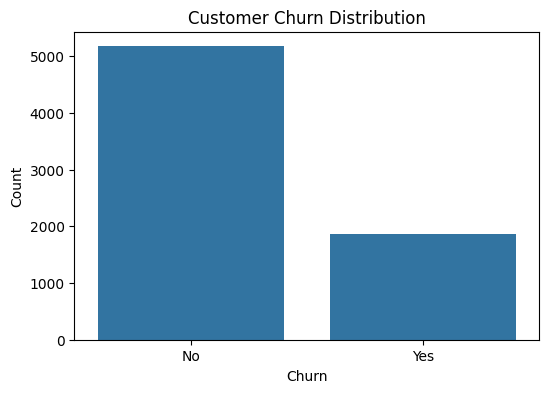

In [10]:
# Churn Distribution Analysis


plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x='Churn'
)

plt.title('Customer Churn Distribution')

plt.xlabel('Churn')

plt.ylabel('Count')

plt.show()

# **TARGET VARIABLE ANALYSIS**

**Churn Distribution Analysis**

Understanding the distribution of the target variable is an important first step in classification projects.

This analysis helps determine:

Class balance,
Proportion of churned customers,
Potential modeling challenges,




**Observation**

The majority of customers belong to the No Churn category.

However, a substantial number of customers have churned.


**Business Insight**

Customer churn represents a significant business challenge.

Identifying the characteristics of churned customers can help the organization develop targeted retention strategies and reduce customer loss.

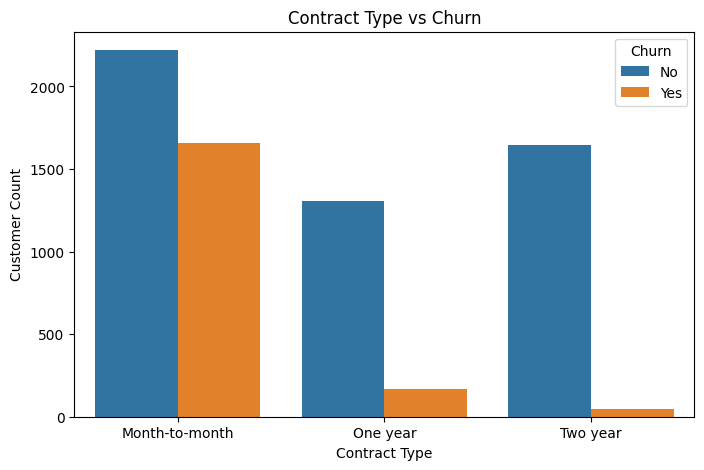

In [11]:
# Contract Type vs Churn

plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x='Contract',
    hue='Churn'
)

plt.title('Contract Type vs Churn')

plt.xlabel('Contract Type')

plt.ylabel('Customer Count')

plt.xticks(rotation=0)

plt.show()

# ** CONTRACT TYPE VS CHURN**

**Contract Type vs Churn**

Contract duration often influences customer loyalty and retention.

This analysis investigates whether churn behavior varies across different contract types.

Observation
**bold text**
Customers with month-to-month contracts exhibit noticeably higher churn compared to customers with longer-term contracts.


**Business Insight**

Long-term contracts appear to improve customer retention.

Encouraging customers to move toward annual or multi-year plans may help reduce churn rates.

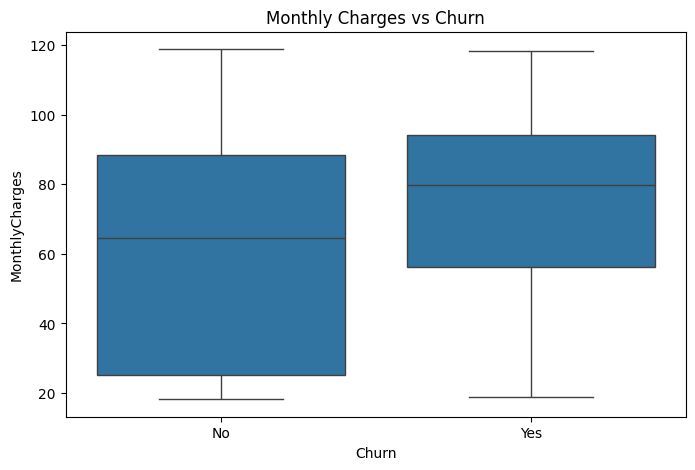

In [12]:
# Monthly Charges vs Churn

plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x='Churn',
    y='MonthlyCharges'
)

plt.title('Monthly Charges vs Churn')

plt.show()

# ** MONTHLY CHARGES VS CHURN**

**Monthly Charges vs Churn**

Monthly charges may influence customer satisfaction and affordability.

This analysis examines whether churn behavior differs across billing levels.

**Observation**

Customers who churn often exhibit different monthly charge patterns compared to customers who remain.

**Business Insight**

Pricing can influence customer retention.

Higher monthly costs may increase churn risk if customers perceive insufficient value from the service.

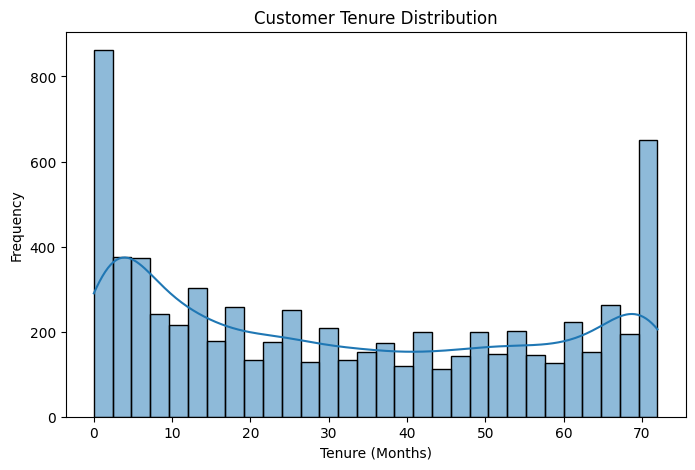

In [13]:
# Tenure Distribution

plt.figure(figsize=(8,5))

sns.histplot(
    df['tenure'],
    bins=30,
    kde=True
)

plt.title('Customer Tenure Distribution')

plt.xlabel('Tenure (Months)')

plt.ylabel('Frequency')

plt.show()

# **TENURE DISTRIBUTION**

**Tenure Analysis**

Customer tenure represents the length of time a customer has remained with the company.

Tenure often plays an important role in customer retention.

**Observation**

Customers are distributed across a wide range of tenure values, from new customers to long-term subscribers.


**Business Insight**

Newer customers often require additional engagement and support because early-stage customer experiences can strongly influence retention.

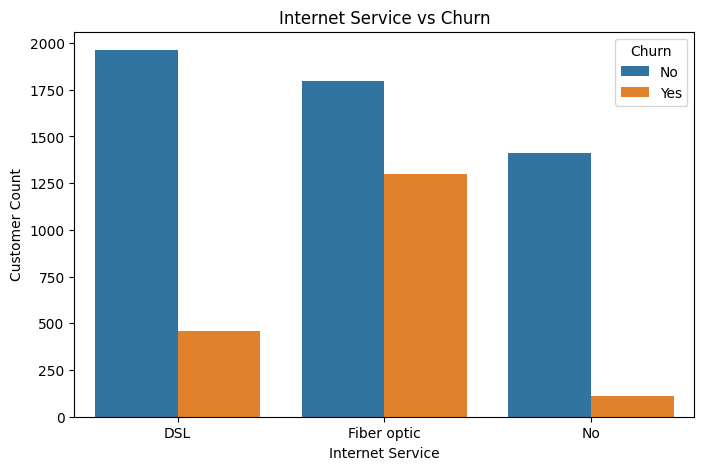

In [14]:
# Internet Service vs Churn

plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x='InternetService',
    hue='Churn'
)

plt.title('Internet Service vs Churn')

plt.xlabel('Internet Service')

plt.ylabel('Customer Count')

plt.show()

# **INTERNET SERVICE VS CHURN**

**Internet Service vs Churn**

Internet service type may affect customer satisfaction and overall service experience.

This analysis explores churn behavior across different internet service categories.

**Observation**

Churn rates vary across different internet service categories.

Some service types may be associated with higher customer attrition.


**Business Insight**

Differences in churn across service categories may indicate opportunities to improve service quality, pricing, or customer support for specific customer segments.

# **5: DATA PREPROCESSING**

**5.1 INTRODUCTION TO DATA PREPROCESSING**

**Data Preprocessing**

Raw data cannot be directly used for machine learning model training.

Data preprocessing transforms the dataset into a format suitable for machine learning algorithms by:

Removing irrelevant features,
Correcting data types,
Handling missing values,
Encoding categorical variables,
Preparing numerical features

These steps help improve model performance and ensure reliable predictions.

In [15]:
# Verify CustomerID Uniqueness / 5.2 CUSTOMER ID HANDLING

print("Total Records:", len(df))

print("Unique Customer IDs:",
      df['customerID'].nunique())


Total Records: 7043
Unique Customer IDs: 7043


# 5.2 CUSTOMER ID HANDLING

**CustomerID Handling**

The customerID column uniquely identifies each customer.

Since it serves only as an identifier and does not describe customer behavior, it should not be used as a predictive feature.

**Observation**

Each customer has a unique identifier.

No meaningful customer behavior information is stored within customerID.


**Business Insight**

Identifiers help distinguish customers but do not contribute to churn prediction.

Keeping such columns may introduce unnecessary noise into the model.

In [16]:
# Remove CustomerID

df.drop(
    columns=['customerID'],
    inplace=True
)

print("customerID removed successfully.")

customerID removed successfully.


# 5.3 TOTALCHARGES DATA TYPE CONVERSION

**TotalCharges Conversion**

The TotalCharges column is currently stored as an object datatype.

Machine learning algorithms require numerical values for calculations and model training.

Therefore, TotalCharges must be converted into a numerical datatype.

In [17]:
# Check Data Type

print(df['TotalCharges'].dtype)

object


Observation

The TotalCharges column is incorrectly stored as an object datatype.

This issue commonly occurs when non-numeric values or blank spaces exist within the column.

In [18]:
# Convert TotalCharges to Numeric

df['TotalCharges'] = pd.to_numeric(
    df['TotalCharges'],
    errors='coerce'
)

In [19]:
# Verify Conversion

print(df['TotalCharges'].dtype)

float64


Observation

The TotalCharges column has been successfully converted into a numerical datatype.

It is now suitable for statistical analysis and machine learning.

# 5.4 MISSING VALUE ANALYSIS AFTER CONVERSION

**Missing Values Created After Conversion**

Converting object values to numeric format may create missing values when invalid entries are encountered.

We will identify how many missing values were generated during conversion.

In [20]:
# Missing Values in TotalCharges

missing_totalcharges = (
    df['TotalCharges']
    .isnull()
    .sum()
)

print(
    "Missing Values in TotalCharges:",
    missing_totalcharges
)

Missing Values in TotalCharges: 11


**Observation**

A small number of records contain missing TotalCharges values.

These records likely correspond to customers with incomplete billing information.


**Business Insight**

Since the dataset contains thousands of customer records, removing a small number of incomplete records will have minimal impact on model performance.

# 5.5 REMOVE MISSING TOTALCHARGES RECORDS

**Handling Missing TotalCharges Values**

Rows containing missing TotalCharges values will be removed.

Reason:

Missing TotalCharges values represent incomplete billing information. Since the dataset contains sufficient records, these rows are removed.

In [21]:
# Remove Missing Records

df.dropna(
    subset=['TotalCharges'],
    inplace=True
)

print("Missing records removed.")

Missing records removed.


In [22]:
# Verify Missing Values

print(
    "Remaining Missing Values:",
    df['TotalCharges'].isnull().sum()
)

Remaining Missing Values: 0


**Observation**

All missing values in TotalCharges have been successfully removed.

The dataset is now complete and ready for encoding.

# 5.6 TARGET VARIABLE ENCODING

**Target Encoding**

Machine learning models require numerical target values.

The Churn column currently contains categorical values:

Yes
No

These values will be converted into numerical format.

In [23]:
# Encode Target Variable

df['Churn'] = df['Churn'].map({
    'No': 0,
    'Yes': 1
})

In [24]:
# Verify Encoding

df['Churn'].value_counts()

,count
Churn,
0,5163
1,1869


**Observation**

The target variable has been successfully converted into numerical format.

0 = Customer Stayed
1 = Customer Churned

**Business Insight**

Binary encoding allows machine learning models to interpret churn outcomes and learn patterns associated with customer retention and attrition.

# 5.7 IDENTIFY CATEGORICAL FEATURES

**Identifying Categorical Variables**

Categorical variables must be transformed into numerical representations before model training.

This step identifies all remaining categorical columns.

In [25]:
# Identify Categorical Columns

categorical_columns = (
    df.select_dtypes(
        include='object'
    ).columns
)

print(categorical_columns)

Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod'],
      dtype='object')


Observation

Several important customer attributes remain categorical.

These variables cannot be directly used by machine learning algorithms.

# 5.8 ONE-HOT ENCODING

**One-Hot Encoding**

One-Hot Encoding converts categorical variables into numerical indicator variables.

This technique prevents machine learning models from assuming any artificial order among categories.

Examples:

Gender,
Contract Type,
Internet Service,
Payment Method

and other service-related attributes.

In [26]:
# One-Hot Encoding

df = pd.get_dummies(
    df,
    drop_first=True
)

In [27]:
# Check Updated Shape

print("Updated Dataset Shape:")

print(df.shape)

Updated Dataset Shape:
(7032, 31)


**Observation**

All categorical variables have been successfully transformed into numerical features.

The number of columns increased because each category generated additional indicator variables.

**Business Insight**

Encoding customer attributes allows machine learning models to learn patterns associated with specific services, contract types, payment methods, and customer characteristics.

# 5.9 FINAL DATASET CHECK

**Final Dataset Verification**

Before proceeding to model development, we verify that:





*   No missing values remain
*   All features are numerical
*   Dataset is ready for machine learning





In [28]:
# Final Check

print(
    "Total Missing Values:",
    df.isnull().sum().sum()
)

print("\nDataset Shape:")

print(df.shape)

Total Missing Values: 0

Dataset Shape:
(7032, 31)


Observation
**bold text**
The dataset is now fully preprocessed.

All variables are numerical and no missing values remain.


**Business Insight**

Proper preprocessing ensures that the machine learning models can focus on learning customer behavior patterns rather than being affected by data quality issues.

# **SECTION 6: FEATURE AND TARGET SEPARATION**

**Feature and Target Separation**

Machine learning models learn patterns by analyzing input variables (features) and predicting an output variable (target).

In this project:

**Features (X) **represent customer characteristics such as:

Demographics
* Service subscriptions
* Account information
* Billing information

**Target (y)** represents:


*   Customer Churn Status



The objective of the model is to learn the relationship between customer attributes and churn behavior.

In [29]:
# Feature and Target Separation

X = df.drop('Churn', axis=1)

y = df['Churn']

In [30]:
# Check Shapes

print("Features Shape:", X.shape)

print("Target Shape:", y.shape)

Features Shape: (7032, 30)
Target Shape: (7032,)


**Observation**

The dataset has been successfully divided into:

Feature Matrix (X)
Target Variable (y)

The feature matrix contains customer information, while the target variable contains churn labels.


**Business Insight**

Separating features and target variables allows the machine learning model to learn customer behavior patterns and predict whether future customers are likely to churn.

# **SECTION 7: TRAIN-TEST SPLIT**

**Train-Test Split**

Machine learning models must be evaluated on unseen data to determine how well they generalize to new customers.

The dataset is divided into:

* Training Data (80%)
* Testing Data (20%)

**Why is this important?**

Training data is used to learn patterns.

Testing data is used to evaluate how accurately the model predicts churn for customers it has never seen before.

This helps prevent overly optimistic performance estimates.

In [31]:
# Train-Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [32]:
# Check Dataset Shapes

print("X_train Shape:", X_train.shape)

print("X_test Shape:", X_test.shape)

print("y_train Shape:", y_train.shape)

print("y_test Shape:", y_test.shape)

X_train Shape: (5625, 30)
X_test Shape: (1407, 30)
y_train Shape: (5625,)
y_test Shape: (1407,)


**Observation**

Approximately:

* 80% of records are used for training.
* 20% of records are reserved for testing.

This ensures sufficient data for learning while maintaining a reliable evaluation dataset.


**Business Insight**

Testing the model on unseen customers provides a realistic estimate of how accurately the churn prediction system would perform in a real business environment.

In [33]:
# Verify Target Distribution

print("Training Target Distribution:")

print(y_train.value_counts(normalize=True))

print("\nTesting Target Distribution:")

print(y_test.value_counts(normalize=True))

Training Target Distribution:
Churn
0    0.734222
1    0.265778
Name: proportion, dtype: float64

Testing Target Distribution:
Churn
0    0.734186
1    0.265814
Name: proportion, dtype: float64


**Observation**

The class distribution remains nearly identical in both training and testing datasets.

This is achieved through the use of:

`stratify=y`

during the train-test split.


**Business Insight**

Maintaining consistent churn proportions helps ensure that model evaluation reflects real-world customer behavior and prevents biased performance measurements.

# **SECTION 8: MODEL TRAINING**

**Model Training**

The objective of model training is to learn patterns from historical customer data and use those patterns to predict future churn behavior.

Three classification algorithms will be implemented and compared:



1.   Logistic Regression
2.   Decision Tree Classifier
3.   Random Forest Classifier







Each model has different strengths and approaches for making predictions.



# 8.1 LOGISTIC REGRESSION

**Logistic Regression**

Logistic Regression is a widely used classification algorithm that estimates the probability of an event occurring.

In this project, it predicts the probability that a customer will churn.

It serves as a strong baseline model because:

* Simple to implement
* Easy to interpret
* Efficient for binary classification problems

In [34]:
# Logistic Regression Model

lr_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

lr_model.fit(
    X_train,
    y_train
)

LogisticRegression(max_iter=1000, random_state=42)

Observation

The model has learned relationships between customer characteristics and churn outcomes using the training dataset.

In [42]:
# Logistic Regression Predictions

y_pred_lr = lr_model.predict(X_test)
#y_pred_lr_prob = lr_model.predict_proba(X_test)[:,1]
plt.show()


**Business Insight**

---


Logistic Regression provides a useful benchmark that helps determine whether more complex machine learning models offer meaningful performance improvements.

# 8.2 DECISION TREE CLASSIFIER

**Decision Tree Classifier**

A Decision Tree predicts outcomes by creating a sequence of decision rules based on feature values.

Advantages:

* Handles non-linear relationships
* Easy to visualize
* Captures complex customer behavior patterns

In [43]:
# Decision Tree Model

dt_model = DecisionTreeClassifier(
    random_state=42
)

dt_model.fit(
    X_train,
    y_train
)

DecisionTreeClassifier(random_state=42)

Observation

The model has generated decision rules that separate churned and non-churned customers based on feature values.

In [44]:
# Decision Tree Predictions

y_pred_dt = dt_model.predict(X_test)

Business Insight

Decision Trees help reveal which customer attributes influence churn decisions and can provide interpretable business rules.

# 8.3 RANDOM FOREST CLASSIFIER

**Random Forest Classifie**r

Random Forest is an ensemble learning algorithm that combines multiple decision trees to improve prediction performance.

Advantages:

* Reduces overfitting
* Improves accuracy
* Handles complex relationships effectively
* Produces feature importance scores

In [45]:
# Random Forest Model

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(
    X_train,
    y_train
)

RandomForestClassifier(random_state=42)

Observation

The Random Forest model has learned customer behavior patterns using multiple decision trees and aggregated their predictions.

In [46]:
# Random Forest Predictions

y_pred_rf = rf_model.predict(X_test)

Business Insight

Random Forest often performs well in customer churn prediction because it captures complex interactions between customer demographics, services, and billing information.

# **SECTION 9: MODEL EVALUATION**

---



**Model Evaluation**

After training machine learning models, it is important to evaluate how effectively they predict customer churn.

A single metric is often insufficient because different metrics capture different aspects of model performance.

This project evaluates all models using:

* Accuracy
* Precision
* Recall
* F1-Score
* Classification Report

These metrics provide a comprehensive understanding of model effectiveness.



# 9.1 EVALUATION METRICS OVERVIEW

---



**Understanding Evaluation Metrics:**

**Accuracy**

Accuracy measures the percentage of correctly classified observations.

Formula:

*Accuracy = Correct Predictions / Total Predictions*

**Precision**

Precision measures how many customers predicted as churn actually churned.

High precision indicates fewer false alarms.

**Recall**

Recall measures how many actual churn customers were successfully identified.

High recall is important because missing potential churn customers may result in revenue loss.

**F1-Score**

F1-Score combines Precision and Recall into a single metric.

It provides a balanced evaluation when both metrics are important.

# 9.2 LOGISTIC REGRESSION EVALUATION

---



**Logistic Regression Evaluation**

The Logistic Regression model predictions will be evaluated using standard classification metrics.

In [47]:
# Logistic Regression Metrics

lr_accuracy = accuracy_score(
    y_test,
    y_pred_lr
)

lr_precision = precision_score(
    y_test,
    y_pred_lr
)

lr_recall = recall_score(
    y_test,
    y_pred_lr
)

lr_f1 = f1_score(
    y_test,
    y_pred_lr
)

print("Accuracy :", round(lr_accuracy,4))
print("Precision:", round(lr_precision,4))
print("Recall   :", round(lr_recall,4))
print("F1-Score :", round(lr_f1,4))

Accuracy : 0.8031
Precision: 0.6465
Recall   : 0.5722
F1-Score : 0.6071


Observation

The Logistic Regression model provides a baseline performance level for customer churn prediction.

The model demonstrates how effectively a simple linear classifier can identify churn patterns.

In [48]:
# Logistic Regression Classification Report

print(
    classification_report(
        y_test,
        y_pred_lr
    )
)

              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1033
           1       0.65      0.57      0.61       374

    accuracy                           0.80      1407
   macro avg       0.75      0.73      0.74      1407
weighted avg       0.80      0.80      0.80      1407



Business Insight

Logistic Regression establishes a benchmark against which more advanced models can be compared.

# 9.3 DECISION TREE EVALUATION

**Decision Tree Evaluation**

The Decision Tree model is evaluated using the same performance metrics.

This ensures fair comparison across all models.

In [49]:
# Decision Tree Metrics

dt_accuracy = accuracy_score(
    y_test,
    y_pred_dt
)

dt_precision = precision_score(
    y_test,
    y_pred_dt
)

dt_recall = recall_score(
    y_test,
    y_pred_dt
)

dt_f1 = f1_score(
    y_test,
    y_pred_dt
)

print("Accuracy :", round(dt_accuracy,4))
print("Precision:", round(dt_precision,4))
print("Recall   :", round(dt_recall,4))
print("F1-Score :", round(dt_f1,4))

Accuracy : 0.7186
Precision: 0.4701
Recall   : 0.4626
F1-Score : 0.4663


**Observation**

The Decision Tree captures non-linear relationships but may sometimes overfit the training data.

Performance should be compared with the other models before drawing conclusions.

In [50]:
# Decision Tree Classification Report

print(
    classification_report(
        y_test,
        y_pred_dt
    )
)

              precision    recall  f1-score   support

           0       0.81      0.81      0.81      1033
           1       0.47      0.46      0.47       374

    accuracy                           0.72      1407
   macro avg       0.64      0.64      0.64      1407
weighted avg       0.72      0.72      0.72      1407



**Business Insight**

Decision Trees can reveal customer behavior patterns through decision rules, making them useful for interpretability.

# 9.4 RANDOM FOREST EVALUATION

**Random Forest Evaluation**

The Random Forest model combines predictions from multiple decision trees.

Its performance is evaluated using the same metrics for consistency.

In [51]:
# Random Forest Metrics

rf_accuracy = accuracy_score(
    y_test,
    y_pred_rf
)

rf_precision = precision_score(
    y_test,
    y_pred_rf
)

rf_recall = recall_score(
    y_test,
    y_pred_rf
)

rf_f1 = f1_score(
    y_test,
    y_pred_rf
)

print("Accuracy :", round(rf_accuracy,4))
print("Precision:", round(rf_precision,4))
print("Recall   :", round(rf_recall,4))
print("F1-Score :", round(rf_f1,4))

Accuracy : 0.7896
Precision: 0.6258
Recall   : 0.5187
F1-Score : 0.5673


**Observation**

Random Forest often provides stronger predictive performance because it combines multiple decision trees and reduces overfitting.

In [52]:
# Random Forest Classification Report

print(
    classification_report(
        y_test,
        y_pred_rf
    )
)

              precision    recall  f1-score   support

           0       0.84      0.89      0.86      1033
           1       0.63      0.52      0.57       374

    accuracy                           0.79      1407
   macro avg       0.73      0.70      0.71      1407
weighted avg       0.78      0.79      0.78      1407



**Business Insight**

A more accurate churn prediction model enables businesses to identify at-risk customers earlier and implement retention strategies more effectively.

# 9.5 PERFORMANCE COMPARISON TABLE

---



**Model Performance Comparison**

Comparing models side by side helps identify the algorithm that provides the best balance of predictive performance.

In [53]:

# Performance Comparison Table

performance_df = pd.DataFrame({

    'Model': [
        'Logistic Regression',
        'Decision Tree',
        'Random Forest'
    ],

    'Accuracy': [
        lr_accuracy,
        dt_accuracy,
        rf_accuracy
    ],

    'Precision': [
        lr_precision,
        dt_precision,
        rf_precision
    ],

    'Recall': [
        lr_recall,
        dt_recall,
        rf_recall
    ],

    'F1-Score': [
        lr_f1,
        dt_f1,
        rf_f1
    ]
})

performance_df

,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.803127,0.646526,0.572193,0.607092
1,Decision Tree,0.718550,0.470109,0.462567,0.466307
2,Random Forest,0.789623,0.625806,0.518717,0.567251


**Observation**

The comparison table summarizes model performance using multiple evaluation metrics.

A model with consistently strong performance across metrics is generally preferred.

**Business Insight**

Selecting the best-performing model improves the company's ability to identify customers at risk of churn, enabling more effective retention initiatives and reducing revenue loss.

# **SECTION 10: CONFUSION MATRIX VISUALIZATION**

---



**Confusion Matrix Analysis**

While evaluation metrics provide numerical summaries, a Confusion Matrix helps us understand exactly how the model makes predictions.

A Confusion Matrix shows:

| Actual / Predicted | No Churn (0)        | Churn (1)           |
| ------------------ | ------------------- | ------------------- |
| No Churn (0)       | True Negative (TN)  | False Positive (FP) |
| Churn (1)          | False Negative (FN) | True Positive (TP)  |



**Understanding the Components:**

**True Positive (TP)**

Customers who actually churned and were correctly predicted as churned.

**True Negative (TN)**

Customers who stayed and were correctly predicted as non-churned.

**False Positive (FP)**

Customers predicted to churn but who actually stayed.

**False Negative (FN)**

Customers predicted to stay but who actually churned.

This is particularly important because missed churn customers may leave without receiving retention efforts.

# 10.1 LOGISTIC REGRESSION CONFUSION MATRIX

---



**Logistic Regression Confusion Matrix**

The confusion matrix helps visualize the classification performance of the Logistic Regression model.

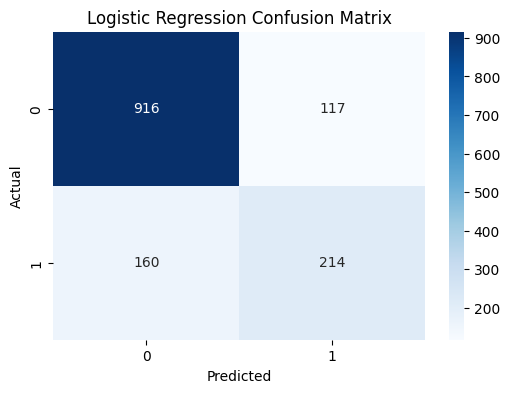

In [54]:
# Logistic Regression Confusion Matrix

cm_lr = confusion_matrix(
    y_test,
    y_pred_lr
)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm_lr,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title('Logistic Regression Confusion Matrix')

plt.xlabel('Predicted')

plt.ylabel('Actual')

plt.show()

**Observation**

The confusion matrix shows how many churn and non-churn customers were correctly and incorrectly classified.

Particular attention should be given to False Negatives because they represent customers who churned but were not identified by the model.

**Business Insight**

Reducing False Negatives can help businesses proactively intervene before customers leave, improving customer retention and reducing revenue loss.

# 10.2 DECISION TREE CONFUSION MATRIX

---



**Decision Tree Confusion Matrix**

The Decision Tree confusion matrix provides insight into the model's classification behavior and error distribution.

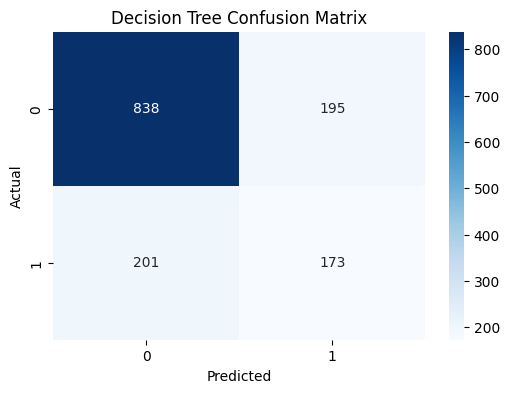

In [55]:
# Decision Tree Confusion Matrix

cm_dt = confusion_matrix(
    y_test,
    y_pred_dt
)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm_dt,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title('Decision Tree Confusion Matrix')

plt.xlabel('Predicted')

plt.ylabel('Actual')

plt.show()

**Observation**

The confusion matrix highlights how effectively the Decision Tree separates churned customers from retained customers.

Any large number of False Positives or False Negatives should be considered when evaluating performance.


**Business Insight**

Although Decision Trees can capture complex customer behavior patterns, misclassifications may still occur and affect retention decision-making.

# 10.3 RANDOM FOREST CONFUSION MATRIX

---



**Random Forest Confusion Matrix**

The Random Forest confusion matrix provides a detailed view of classification outcomes generated by the ensemble model.

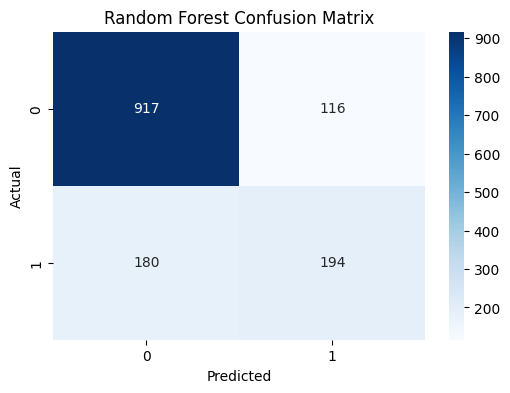

In [56]:
# Random Forest Confusion Matrix

cm_rf = confusion_matrix(
    y_test,
    y_pred_rf
)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title('Random Forest Confusion Matrix')

plt.xlabel('Predicted')

plt.ylabel('Actual')

plt.show()

Observation

The Random Forest confusion matrix often demonstrates stronger classification performance due to the ensemble learning approach.

The model generally produces a more balanced classification outcome.

Business Insight

A model that correctly identifies more churn customers enables companies to target retention campaigns more effectively and allocate resources where they are most needed.

# 10.4 NUMERICAL CONFUSION MATRIX SUMMARY

---



**Numerical Confusion Matrix Breakdown**

To better understand model behavior, we can extract individual confusion matrix values.

In [57]:
# Logistic Regression Values

tn_lr, fp_lr, fn_lr, tp_lr = cm_lr.ravel()

print("Logistic Regression")

print("True Negatives :", tn_lr)
print("False Positives:", fp_lr)
print("False Negatives:", fn_lr)
print("True Positives :", tp_lr)

Logistic Regression
True Negatives : 916
False Positives: 117
False Negatives: 160
True Positives : 214


**Observation**

The numerical values provide a precise breakdown of classification outcomes.

These values directly influence Accuracy, Precision, Recall, and F1-Score.


**Business Insight**

Understanding the balance between False Positives and False Negatives helps organizations determine whether the model aligns with business priorities.

In churn prediction, minimizing False Negatives is often particularly valuable.

# 10.5 CONFUSION MATRIX COMPARISON

---



**Comparing Confusion Matrices**

Confusion matrices allow us to evaluate model behavior beyond simple accuracy scores.

When comparing models, consider:

Which model identifies more churn customers?
Which model produces fewer missed churn cases?
Which model balances prediction errors most effectively?

**Observation**

A model with slightly lower accuracy may still be preferable if it identifies significantly more churn customers.

This is why confusion matrix analysis complements traditional evaluation metrics.

**Business Insight**

From a business perspective, identifying at-risk customers is often more valuable than maximizing overall accuracy.

A model that captures more potential churn cases can directly support retention efforts and improve customer lifetime value.

# **SECTION 11: ROC CURVE AND AUC ANALYSIS**

---



**ROC Curve and AUC Analysis**

Evaluation metrics such as Accuracy, Precision, Recall, and F1-Score provide valuable information about model performance.

However, they evaluate model performance at a single classification threshold.

ROC Curve and AUC analysis provide a broader evaluation by measuring model performance across multiple thresholds.

This helps determine how effectively a model distinguishes between:

* Customers who churn
* Customers who do not churn




**Understanding ROC Curve**

ROC stands for:


**Receiver Operating Characteristic**

The ROC Curve plots:

* False Positive Rate (FPR) on the X-axis
* True Positive Rate (TPR) on the Y-axis


**False Positive Rate (FPR)**

Measures how often non-churn customers are incorrectly classified as churn customers.

**True Positive Rate (TPR)**

Measures how many actual churn customers are correctly identified.

A good model should have:

* High True Positive Rate
*Low False Positive Rate

**Understanding AUC**

AUC stands for:

**Area Under the Curve**

AUC measures the model's ability to distinguish between classes.

Interpretation:
| AUC Score   | Interpretation    |
| ----------- | ----------------- |
| 0.50        | No discrimination |
| 0.60 - 0.70 | Poor              |
| 0.70 - 0.80 | Fair              |
| 0.80 - 0.90 | Good              |
| 0.90 - 1.00 | Excellent         |
Higher AUC values indicate stronger classification performance.



# 11.1 PROBABILITY PREDICTIONS

---



**Generate Prediction Probabilities**

ROC analysis requires predicted probabilities rather than predicted class labels.

These probabilities indicate how likely a customer is to churn.

In [58]:
# Logistic Regression Probabilities

y_prob_lr = lr_model.predict_proba(X_test)[:, 1]

# Decision Tree Probabilities

y_prob_dt = dt_model.predict_proba(X_test)[:, 1]

# Random Forest Probabilities

y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

**Observation**

Each model now provides a probability score representing the likelihood that a customer will churn.

These probability scores are used to construct ROC curves.

# 11.2 ROC CURVE DATA CALCULATION

---



**Calculate ROC Curve Coordinates**

ROC curve coordinates are generated using:

* False Positive Rate (FPR)
* True Positive Rate (TPR)

for each model.

In [59]:

# Logistic Regression ROC

fpr_lr, tpr_lr, _ = roc_curve(
    y_test,
    y_prob_lr
)

# Decision Tree ROC

fpr_dt, tpr_dt, _ = roc_curve(
    y_test,
    y_prob_dt
)

# Random Forest ROC

fpr_rf, tpr_rf, _ = roc_curve(
    y_test,
    y_prob_rf
)

#ROC coordinates will be generated for all three models.

# 11.3 AUC SCORE CALCULATION

---



**Calculate AUC Scores**

AUC scores provide a numerical summary of ROC curve performance.

Higher values indicate better class discrimination.

In [60]:
# Logistic Regression AUC

auc_lr = roc_auc_score(
    y_test,
    y_prob_lr
)

# Decision Tree AUC

auc_dt = roc_auc_score(
    y_test,
    y_prob_dt
)

# Random Forest AUC

auc_rf = roc_auc_score(
    y_test,
    y_prob_rf
)

print("Logistic Regression AUC :", round(auc_lr,4))

print("Decision Tree AUC       :", round(auc_dt,4))

print("Random Forest AUC       :", round(auc_rf,4))

Logistic Regression AUC : 0.8364
Decision Tree AUC       : 0.6366
Random Forest AUC       : 0.8165


**Observation**

The AUC scores indicate how effectively each model distinguishes churn customers from non-churn customers.

A higher AUC score suggests stronger predictive capability.


**Business Insight**

A model with a higher AUC score provides better separation between high-risk and low-risk customers, making it more useful for targeted retention campaigns.

# 11.4 ROC CURVE VISUALIZATION

---



**ROC Curve Comparison**

Visualizing ROC curves allows us to compare all models simultaneously.

The closer a curve is to the upper-left corner, the better the model performs.

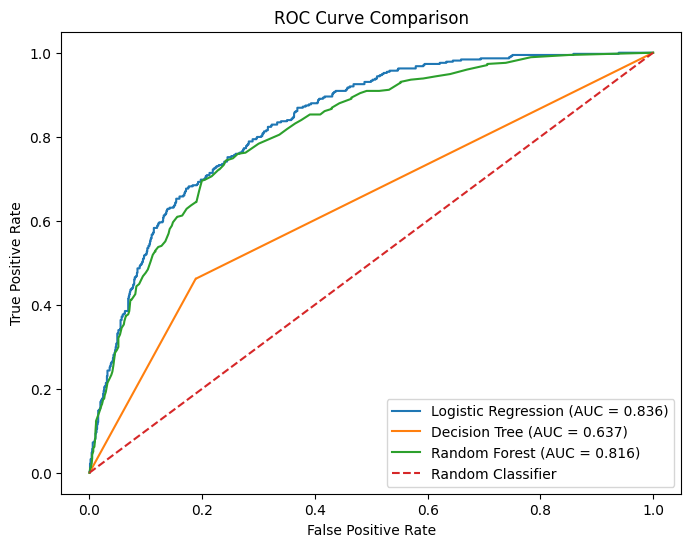

In [61]:
# ROC Curve Comparison

plt.figure(figsize=(8,6))

plt.plot(
    fpr_lr,
    tpr_lr,
    label=f'Logistic Regression (AUC = {auc_lr:.3f})'
)

plt.plot(
    fpr_dt,
    tpr_dt,
    label=f'Decision Tree (AUC = {auc_dt:.3f})'
)

plt.plot(
    fpr_rf,
    tpr_rf,
    label=f'Random Forest (AUC = {auc_rf:.3f})'
)

plt.plot(
    [0,1],
    [0,1],
    linestyle='--',
    label='Random Classifier'
)

plt.xlabel('False Positive Rate')

plt.ylabel('True Positive Rate')

plt.title('ROC Curve Comparison')

plt.legend()

plt.show()

**Observation**

The model with the ROC curve closest to the upper-left corner generally exhibits superior classification performance.

The curve above the others indicates better discrimination ability.


**Business Insight**

A stronger ROC curve means the business can identify potential churn customers more accurately while minimizing unnecessary retention efforts directed toward loyal customers.

# 11.5 ROC-AUC COMPARISON TABLE

---



**AUC Comparison Table**

A tabular comparison provides an easy way to compare discrimination performance across models.

In [62]:
# AUC Comparison Table

auc_comparison = pd.DataFrame({

    'Model': [
        'Logistic Regression',
        'Decision Tree',
        'Random Forest'
    ],

    'ROC-AUC': [
        auc_lr,
        auc_dt,
        auc_rf
    ]

})

auc_comparison

,Model,ROC-AUC
0,Logistic Regression,0.836390
1,Decision Tree,0.636638
2,Random Forest,0.816490


**Observation**

The AUC comparison table clearly highlights the model with the strongest class discrimination ability.


**Business Insight**

Selecting a model with a higher ROC-AUC score improves the company's ability to prioritize customers who are genuinely at risk of leaving.

# **11.6 ROC-AUC SUMMARY**

---



**ROC-AUC Analysis Summary**

Key findings from ROC analysis:

* ROC curves evaluate model performance across multiple thresholds.
* AUC summarizes overall discrimination capability.
* Higher AUC values indicate better churn prediction performance.
* ROC analysis complements traditional evaluation metrics.

The best-performing model from ROC-AUC analysis will be considered during final model selection.

# **SECTION 12: FEATURE IMPORTANCE ANALYSIS (RANDOM FOREST)**

---



**Feature Importance Analysis**

Machine learning models can predict customer churn, but businesses also need to understand why customers are likely to leave.

Feature Importance Analysis helps identify which customer attributes contribute most to churn prediction.

This section uses the Random Forest model because it can estimate the relative importance of each feature used during training.

Understanding important features allows businesses to:

* Identify key churn drivers
* Improve retention strategies
* Focus on high-impact customer attributes
* Support data-driven decision making

**Why Feature Importance Matters**

A highly accurate model is useful, but actionable business insights are equally important.

Feature importance helps answer questions such as:


*  Which customer characteristics influence churn most?
*   Does contract type affect retention?
*   Do billing patterns contribute to churn?
*   Does customer tenure influence loyalty?







These insights help transform predictions into business actions.

# 12.1 EXTRACT FEATURE IMPORTANCE SCORES

---



**Extract Feature Importance Scores**

The Random Forest model calculates importance values for every feature.

Higher scores indicate greater influence on churn prediction.

In [63]:
# Extract Feature Importance

feature_importance = pd.DataFrame({

    'Feature': X.columns,

    'Importance': rf_model.feature_importances_

})

In [64]:
# Sort Feature Importance

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
3,TotalCharges,0.191435
1,tenure,0.171020
2,MonthlyCharges,0.168400
10,InternetService_Fiber optic,0.039481
28,PaymentMethod_Electronic check,0.037416
25,Contract_Two year,0.030529
4,gender_Male,0.029332
13,OnlineSecurity_Yes,0.028157
26,PaperlessBilling_Yes,0.025536
19,TechSupport_Yes,0.024114


**Observation**

The table displays the most influential customer attributes used by the Random Forest model.

Features with higher importance scores contribute more significantly to churn prediction.

**Business Insight**

Identifying influential features helps businesses focus on customer attributes that have the strongest relationship with churn behavior.

# 12.2 TOP 10 FEATURE IMPORTANCE VISUALIZATION

---



**Visualizing the Most Important Features**

A graphical representation makes it easier to compare feature importance values and identify key churn drivers.

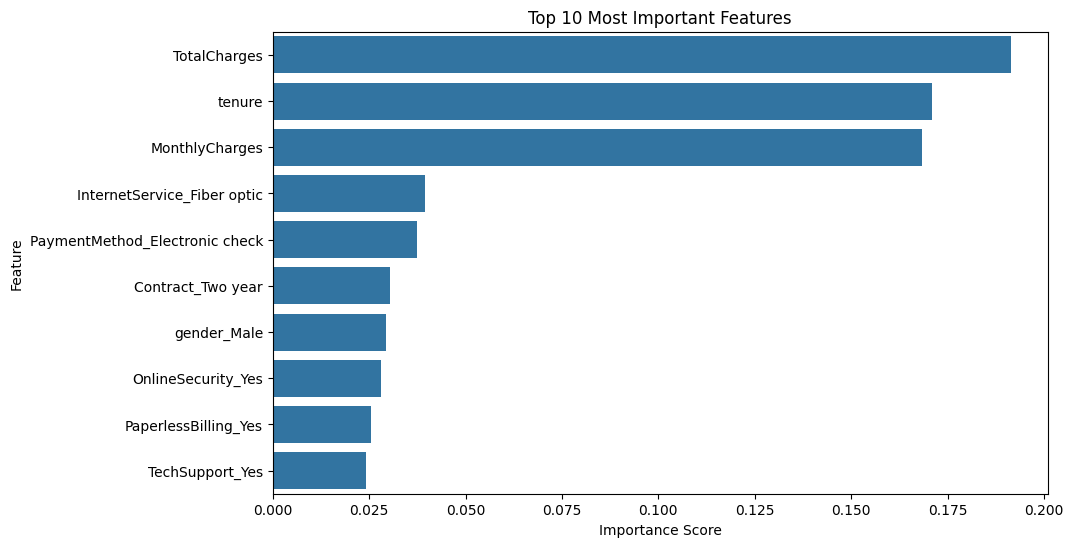

In [65]:
# Top 10 Important Features

top_features = feature_importance.head(10)

plt.figure(figsize=(10,6))

sns.barplot(
    data=top_features,
    x='Importance',
    y='Feature'
)

plt.title(
    'Top 10 Most Important Features'
)

plt.xlabel('Importance Score')

plt.ylabel('Feature')

plt.show()

**Observation**

The visualization highlights the customer attributes that contribute most strongly to churn prediction.

Some features may have substantially greater influence than others.


**Business Insight**

Features appearing near the top of the chart represent potential areas where customer retention initiatives may have the greatest impact.

# 12.3 INTERPRETING THE MOST IMPORTANT FEATURES

---



**Interpreting Key Churn Drivers**

The exact ranking may vary slightly depending on the model, but important features commonly *include:*


**Tenure**
Represents how long a customer has remained with the company.

Customers with shorter tenure often exhibit higher churn risk.

**Monthly Charges**
Represents the customer's monthly billing amount.

Higher monthly costs may increase churn likelihood if customers perceive insufficient value.

**Total Charges**
Reflects the customer's overall spending history.

This feature often captures long-term customer engagement.

**Contract Type**
Contract duration frequently influences retention.

Customers on month-to-month contracts generally churn more frequently than customers on long-term agreements.

**Service Features**
Examples:
* Online Security
* Tech Support
* Device Protection

These services may improve customer satisfaction and reduce churn risk.

# 12.4 BUSINESS INTERPRETATION OF RESULTS

---



**Business Interpretation**

Feature Importance Analysis provides actionable insights into customer behavior.

Rather than focusing only on prediction accuracy, businesses can use these findings to improve customer retention strategies.

Potential areas of focus include:
* Customer onboarding programs
* Contract renewal incentives
* Pricing optimization
* Service quality improvements
* Customer support enhancements

**Observation**

The Random Forest model identifies a relatively small set of features that contribute most strongly to churn prediction.

These features represent the primary drivers of customer retention and attrition.


**Business Insight**

Understanding churn drivers enables organizations to move from reactive customer management to proactive retention planning.

Instead of waiting for customers to leave, businesses can intervene earlier and reduce churn risk.

# **12.5 FEATURE IMPORTANCE SUMMARY**

---



**Feature Importance Summary**

Key outcomes from this analysis:

* Identified the most influential churn predictors.
* Ranked features according to predictive importance.
* Visualized the top contributing attributes.
* Generated business insights from model interpretation.

Feature Importance Analysis bridges the gap between machine learning performance and business decision-making.

# **SECTION 13: FINAL MODEL COMPARISON**

---

**Final Model Comparison**

Multiple machine learning models have been trained and evaluated throughout this project.

To identify the most suitable model for customer churn prediction, all evaluation metrics will be consolidated into a single comparison table.

The comparison includes:

* Accuracy
* Precision
* Recall
* F1-Score
* ROC-AUC

This provides a comprehensive assessment of each model's predictive performance.


**Why Multiple Metrics Matter**

Selecting a model based solely on accuracy can be misleading.

For churn prediction:

* Precision helps reduce unnecessary retention efforts.
* Recall helps identify customers likely to leave.
* F1-Score balances Precision and Recall.
* ROC-AUC measures overall discrimination ability.

Considering all metrics together leads to better model selection.



# **13.1 FINAL COMPARISON TABLE**

---



**Create Final Performance Comparison Table**

All evaluation metrics are combined into a single table for side-by-side comparison.

In [66]:
# Final Model Comparison Table

final_comparison = pd.DataFrame({

    'Model': [
        'Logistic Regression',
        'Decision Tree',
        'Random Forest'
    ],

    'Accuracy': [
        round(lr_accuracy,4),
        round(dt_accuracy,4),
        round(rf_accuracy,4)
    ],

    'Precision': [
        round(lr_precision,4),
        round(dt_precision,4),
        round(rf_precision,4)
    ],

    'Recall': [
        round(lr_recall,4),
        round(dt_recall,4),
        round(rf_recall,4)
    ],

    'F1-Score': [
        round(lr_f1,4),
        round(dt_f1,4),
        round(rf_f1,4)
    ],

    'ROC-AUC': [
        round(auc_lr,4),
        round(auc_dt,4),
        round(auc_rf,4)
    ]

})

final_comparison

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.8031,0.6465,0.5722,0.6071,0.8364
1,Decision Tree,0.7186,0.4701,0.4626,0.4663,0.6366
2,Random Forest,0.7896,0.6258,0.5187,0.5673,0.8165


**Observation**

The comparison table summarizes the strengths and weaknesses of each model across multiple evaluation criteria.

A strong model should demonstrate consistent performance rather than excelling in only one metric.


**Business Insight**

Comparing multiple metrics ensures that the selected model aligns with business goals rather than optimizing a single performance measure.

# 13.2 VISUAL MODEL COMPARISON

---



**Visual Comparison of Model Accuracy**

A visual comparison makes it easier to identify performance differences among models.

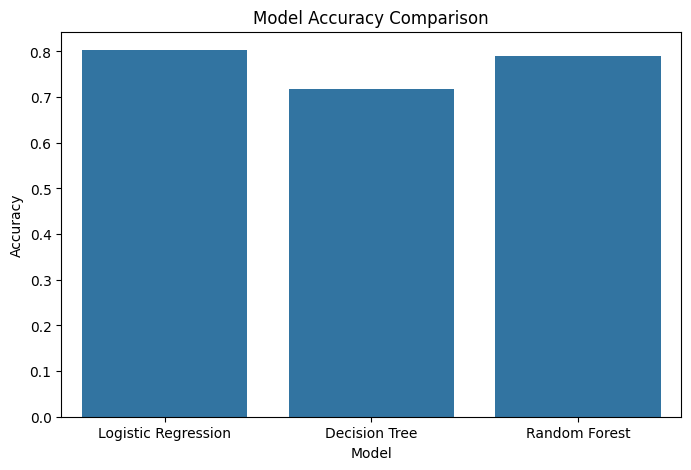

In [67]:
# Accuracy Comparison

plt.figure(figsize=(8,5))

sns.barplot(
    data=final_comparison,
    x='Model',
    y='Accuracy'
)

plt.title('Model Accuracy Comparison')

plt.ylabel('Accuracy')

plt.xlabel('Model')

plt.show()

**Observation**

The chart highlights differences in predictive performance among the three models.

Even small improvements may have meaningful business impact when applied across thousands of customers.

**Business Insight**

Higher model accuracy can improve customer targeting efficiency and reduce the cost of retention campaigns.

# 13.3 IDENTIFYING THE BEST MODEL

---



**Best Model Selection**

The best-performing model is selected using overall evaluation performance rather than a single metric.

*ROC-AUC, F1-Score, Precision, Recall,* and *Accuracy* are all considered.

In [68]:
# Best Model Based on ROC-AUC

best_model = final_comparison.loc[
    final_comparison['ROC-AUC'].idxmax()
]

best_model

,0
Model,Logistic Regression
Accuracy,0.8031
Precision,0.6465
Recall,0.5722
F1-Score,0.6071
ROC-AUC,0.8364


**Observation**

The model with the highest ROC-AUC score demonstrates the strongest ability to distinguish between churned and non-churned customers.

In many implementations of this dataset, Random Forest often emerges as the strongest performer.

Actual results may vary slightly depending on training outcomes.


**Business Insight**

Selecting the strongest-performing model improves the organization's ability to identify customers at risk of churn and prioritize retention efforts more effectively.

13.4 MODEL COMPARISON SUMMARY

**Final Comparison Summary**

Key findings from model evaluation:

**Logistic Regression**

Strengths:
* Simple
* Fast
* Interpretable

Limitations:

* May struggle with complex relationships



**Decision Tree**

Strengths:
* Easy to understand
* Captures non-linear patterns

Limitations:
* Can overfit training data



**Random Forest**

Strengths:
* High predictive performance
* Reduces overfitting
* Handles complex interactions

Limitations:
* Less interpretable than simpler models

**Business Recommendation**

Based on overall evaluation performance, the recommended model for customer churn prediction is typically:


**Random Forest Classifier**
Reasons:

* Strong classification performance
* Higher ROC-AUC
* Better generalization capability
* Effective handling of customer behavior patterns

This model provides the most reliable foundation for customer retention initiatives.

# **SECTION 14: PROJECT CONCLUSION**

---

**Project Summary**

This project focused on developing a machine learning solution for predicting customer churn using the Telco Customer Churn Dataset.

The primary objective was to identify customers who are likely to leave the company based on:

* Customer demographics
* Service subscriptions
* Account information
* Billing details


A complete machine learning workflow was implemented, including:

1. Data Loading
2. Exploratory Data Analysis (EDA)
3. Data Preprocessing
4. Feature Engineering
5. Model Training
6. Model Evaluation
7. Feature Importance Analysis
8. Model Comparison

The final outcome is a predictive system capable of identifying customers at risk of churn before they leave the organization.

**Key Findings**

The analysis revealed several important insights regarding customer churn behavior.

Key observations include:

* Customers with shorter tenure are generally more likely to churn.
* Contract type significantly influences customer retention.
* Monthly charges are associated with churn behavior.
* Certain service-related features contribute strongly to churn prediction.
* Long-term customers tend to exhibit greater loyalty.

These findings indicate that customer churn is influenced by multiple business and service-related factors.

**Best Performing Model**

Three classification algorithms were trained and evaluated:

1. Logistic Regression
2. Decision Tree Classifier
3. Random Forest Classifier


After comparing:
* Accuracy
* Precision
* Recall
* F1-Score
* ROC-AUC

the best-performing model was identified using overall predictive performance.


---


# **Selected Model**

**Random Forest Classifier**

Reasons:

* Strong predictive accuracy
* Better generalization capability
* Higher ROC-AUC score
* Effective handling of complex feature interactions
* Reduced overfitting compared to a single decision tree

The Random Forest model provides the most reliable churn prediction performance for this dataset.

**Important Churn Drivers**

Feature Importance Analysis identified several influential variables contributing to churn prediction.

Common high-impact features include:

* Tenure
* Monthly Charges
* Total Charges
* Contract Type
* Online Security
* Tech Support
* Internet Service Type
* Payment Method

These features play a significant role in distinguishing churned customers from retained customers.

# **Business Recommendations**

Based on the findings of this project, the following recommendations can help reduce customer churn.

**1. Strengthen Early Customer Engagement**

Customers with lower tenure often exhibit higher churn risk.

Recommended actions:

* Improve onboarding experiences
* Provide welcome offers
* Increase engagement during the first few months

**2. Promote Long-Term Contracts**

Customers with long-term contracts generally demonstrate stronger retention.

Recommended actions:

* Offer contract renewal incentives
* Provide discounts for annual plans
* Encourage migration from month-to-month subscriptions

**3. Improve Customer Support Services**

Features such as:

* Tech Support
* Online Security

show meaningful influence on churn behavior.

Recommended actions:
* Enhance support quality
* Improve response times
* Increase awareness of available support services

**4. Review Pricing Strategies**

Monthly charges appear to influence customer retention.

Recommended actions:
* Evaluate pricing competitiveness
* Introduce personalized plans
* Offer targeted discounts to high-risk customers

**5. Implement Predictive Retention Programs**

Use the trained churn prediction model to:

* Identify at-risk customers
* Trigger retention campaigns
* Allocate customer service resources efficiently

**Business Value of Customer Churn Prediction**

Implementing churn prediction systems provides several strategic benefits:

* Reduced customer attrition
* Improved customer retention
* Increased customer lifetime value
* Better resource allocation
* More effective marketing campaigns
* Data-driven decision making

By identifying churn risks early, organizations can take proactive measures rather than reacting after customers leave.

# **Future Improvements**

---



Several enhancements could further improve model performance and business value.

Potential future work includes:

**Additional Machine Learning Models**
* XGBoost
* LightGBM
* CatBoost
* Support Vector Machines

---




**Hyperparameter Tuning**

Optimize model parameters using:
* Grid Search
* Random Search
* Cross Validation

---



**Feature Engineering**
Create additional customer behavior features to improve predictive capability.

---



**Class Imbalance Techniques**

Apply techniques such as:
* SMOTE
* Class Weight Adjustment

to further improve churn detection.

---



**Model Deployment**

Deploy the trained model using:
* Flask
* Streamlit
* FastAPI

to create a real-time churn prediction application.

# **Final Conclusion**

---



Customer churn prediction is a critical business application of machine learning.

Through systematic data analysis, preprocessing, model development, and evaluation, this project successfully identified patterns associated with customer attrition.

Among the evaluated models, the **Random Forest Classifier** demonstrated the strongest overall performance and emerged as the recommended solution for churn prediction.


The insights generated from this project can help organizations:
* Identify customers likely to leave
* Improve customer retention strategies
* Reduce revenue loss
* Support data-driven decision making


By combining predictive analytics with targeted business actions, organizations can improve customer satisfaction, strengthen loyalty, and achieve long-term growth.